In [1]:
os.chdir('..')
print(os.getcwd())

/cephfs/home/kuratov/dnalm


In [300]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='6'

In [28]:
import matplotlib.pyplot as plt

In [2]:
from src.gena_lm.modeling_bert import BertForMaskedLM
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base')
model = BertForMaskedLM.from_pretrained('AIRI-Institute/gena-lm-bert-base')

Some weights of the model checkpoint at AIRI-Institute/gena-lm-bert-base were not used when initializing BertForMaskedLM: ['cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


## Mask LM example with GENA-LM

In [3]:
inputs = tokenizer("ATATACAGC[MASK]ATAGCTGC", return_tensors="pt")
inputs

{'input_ids': tensor([[  1, 324,  29,   4, 183,  32,   2]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

In [4]:
tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

['[CLS]', 'ATATAC', 'AGC', '[MASK]', 'ATAGC', 'TGC', '[SEP]']

In [5]:
# https://huggingface.co/docs/transformers/model_doc/bert#transformers.BertForMaskedLM.forward.example
import torch
with torch.no_grad():
    logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)

In [6]:
mask_token_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]

In [7]:
# get top 10 most probable tokens

In [8]:
values, ind = probs[0, mask_token_index].topk(k=10)
values = values[0].numpy()
ind = ind[0].numpy()
for v, i in zip(values, ind):
    print(v, i, tokenizer.convert_ids_to_tokens([i]))

0.015665434 1062 ['TATATAT']
0.015310603 867 ['TTATAT']
0.014832527 691 ['ACACAC']
0.013761689 612 ['AAATAT']
0.012902452 542 ['ATTTAT']
0.009268548 412 ['ATATATAT']
0.009002218 324 ['ATATAC']
0.007668377 464 ['TTGTC']
0.0065958938 385 ['ATGTC']
0.0061307885 891 ['TATATAA']


In [9]:
# get probabilities for nucleotides:

In [10]:
for t in ['A', 'T', 'G', 'C']:
    t_id = tokenizer.convert_tokens_to_ids(t)
    print(t, t_id, probs[0, mask_token_index, t_id].item())

A 6 4.219936727167806e-06
T 9 3.889549589075614e-06
G 8 2.490487077011494e-06
C 7 4.9966529331868514e-06


## Pathogenic Mutations as Mask LM

### S1A germline variant

In [251]:
import numpy as np
from pathlib import Path
from downstream_tasks.pathogenic_mutations.PathogenicMutationsDataset import PathogenicMutationsDataset

In [252]:
data_file = Path('../data/genomes/downstream_tasks/pathogenic_mutations/S1A_germline_variant_dataset.tsv')
germline_data = PathogenicMutationsDataset(data_file=data_file, tokenizer=tokenizer, max_seq_len=128)

In [13]:
germline_data[0]

{'input_ids': array([    1,  9612,    79, 28777,   887,    26,   801,  8739,   896,
        13278,    91,  6782,  3234,  1816,    17,  7460,   645,   135,
          229,   557, 14781,    49,  1133,  2501,  1278,   123,   181,
          163,   809,   398,   153,   396, 22442,  1161,   120,   321,
          108,  1200, 28030,  2173,  2900,    79,   397,   480,  3765,
         2161,  8421,  8276,    37,   419, 11933,   896,    53,   710,
           79,   798,    22,  1202,   475,   345,   719,   180,   117,
            4,    85,   177, 31599,   896,  6012, 31582,   177,  5096,
         1174,   585,   153,   896,  6012,    40, 12665,   411,   187,
          896,  6012,   250,   211,   135, 31599,  2835,    60,   196,
          561,    32,  2761,   180, 10102,   625,  2903,  3242, 27500,
        10175,  5388,  4550,   661,   265,  3429, 10737,  8205,  1120,
          102,   896,    65,  4372,  2384, 14829,   296,   973,  8355,
          265,   341,  3706,   974,  2086,  2275, 31331,  1146, 

In [303]:
def prepare_model_input(sample, cuda=False):
    return {k: torch.tensor(np.expand_dims(sample[k], axis=0)).cuda() for k in ['input_ids', 'token_type_ids', 'attention_mask']}

In [15]:
with torch.no_grad():
    inputs = prepare_model_input(germline_data[0])
    logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)

In [16]:
# get probabilities for nucleotides:
mask_token_index = (inputs['input_ids']==tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
for t in ['A', 'T', 'G', 'C']:
    t_id = tokenizer.convert_tokens_to_ids(t)
    print(t, t_id, probs[0, mask_token_index, t_id].item())

A 6 2.412755748082418e-05
T 9 5.2746141591342166e-05
G 8 1.6651227952024783e-07
C 7 6.378979742294177e-05


In [17]:
from tqdm.notebook import tqdm

In [18]:
predictions = []
for x in tqdm(germline_data):
    with torch.no_grad():
        inputs = prepare_model_input(x)
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
    ref = x['ref']
    alt = x['alt']
    mask_token_index = (inputs['input_ids'] == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    ref_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(ref)].item()
    alt_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(alt)].item()
    predictions += [{'ref_prob': ref_prob,
                     'alt_prob': alt_prob,
                     'ref': ref,
                     'alt': alt,
                     'pathogenic': x['pathogenic']
                  }]

In [ ]:
import pandas as pd
predictions_df = pd.DataFrame(predictions)

predictions_df['ref_prob>alt_prob'] = predictions_df['ref_prob'] > predictions_df['alt_prob']
predictions_df['ref_prob-alt_prob'] = predictions_df['ref_prob'] - predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob'] = predictions_df['ref_prob'] / predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob_in_[0.5,2.0]'] = (predictions_df['ref_prob/alt_prob']<2.0)&(predictions_df['ref_prob/alt_prob']>0.5)
predictions_df['ref_prob/alt_prob_in_[0.1,10.0]'] = (predictions_df['ref_prob/alt_prob']<10.0)&(predictions_df['ref_prob/alt_prob']>0.1)
predictions_df['ref_prob/alt_prob_in_[0.01,100.0]'] = (predictions_df['ref_prob/alt_prob']<100.0)&(predictions_df['ref_prob/alt_prob']>0.01)

In [288]:
# model is GOOD if
# pathogenic 1: ref_prob > alt_prob
# pathogenic 0: ref_prob ~ alt_prob

In [289]:
def get_label(ref_prob, alt_prob, scale=2.0):
    ratio = ref_prob / alt_prob
    if ratio > scale:
        return 1
    return 0

In [290]:
scales = [1/50, 0.1, 0.25, 0.5, 1.0, 1.15, 1.5, 2.0, 4.0, 8.0, 10, 50]
for scale in scales:
    predictions_df[f'prediction_{scale}'] = predictions_df.apply(lambda x: get_label(x['ref_prob'], x['alt_prob'], scale=scale), axis=1)

In [291]:
predictions_df.corr()

,ref_prob,alt_prob,pathogenic,ref_prob>alt_prob,ref_prob-alt_prob,ref_prob/alt_prob,"ref_prob/alt_prob_in_[0.5,2.0]","ref_prob/alt_prob_in_[0.1,10.0]","ref_prob/alt_prob_in_[0.01,100.0]",prediction_0.02,...,prediction_0.25,prediction_0.5,prediction_1.0,prediction_1.15,prediction_1.5,prediction_2.0,prediction_4.0,prediction_8.0,prediction_10,prediction_50
ref_prob,1.000000,-0.074018,0.022767,0.372181,0.719330,0.129166,-0.100766,-0.182917,-0.197978,0.226984,...,0.288328,0.318323,0.372181,0.382074,0.394038,0.415791,0.469691,0.498494,0.505038,0.524297
alt_prob,-0.074018,1.000000,0.017921,-0.346728,-0.746006,-0.010191,-0.120545,-0.233720,-0.281242,-0.471838,...,-0.445551,-0.407903,-0.346728,-0.336134,-0.321664,-0.301763,-0.259618,-0.236368,-0.228428,-0.188691
pathogenic,0.022767,0.017921,1.000000,0.047060,0.002720,0.039420,0.065159,0.013245,0.031993,0.022138,...,0.061431,0.055915,0.047060,0.037866,0.004715,-0.003640,0.011151,0.016732,0.017594,0.026252
ref_prob>alt_prob,0.372181,-0.346728,0.047060,1.000000,0.490055,0.022675,0.022900,0.090311,0.090551,0.505652,...,0.668446,0.765495,1.000000,0.941580,0.836643,0.754455,0.613127,0.546162,0.524162,0.426190
ref_prob-alt_prob,0.719330,-0.746006,0.002720,0.490055,1.000000,0.093352,0.016680,0.040658,0.063704,0.480246,...,0.502898,0.496704,0.490055,0.489281,0.487192,0.487855,0.494491,0.497529,0.496368,0.481549
ref_prob/alt_prob,0.129166,-0.010191,0.039420,0.022675,0.093352,1.000000,-0.013471,-0.023532,-0.034875,0.011466,...,0.015158,0.017358,0.022675,0.024082,0.027102,0.030054,0.036980,0.041513,0.043255,0.053186
"ref_prob/alt_prob_in_[0.5,2.0]",-0.100766,-0.120545,0.065159,0.022900,0.016680,-0.013471,1.000000,0.572421,0.386028,0.311035,...,0.411172,0.470869,0.022900,-0.076652,-0.273214,-0.448262,-0.364291,-0.324504,-0.311433,-0.253222
"ref_prob/alt_prob_in_[0.1,10.0]",-0.182917,-0.233720,0.013245,0.090311,0.040658,-0.023532,0.572421,1.000000,0.674377,0.543368,...,0.488825,0.349149,0.090311,0.033546,-0.077719,-0.175924,-0.379683,-0.499827,-0.544062,-0.442370
"ref_prob/alt_prob_in_[0.01,100.0]",-0.197978,-0.281242,0.031993,0.090551,0.063704,-0.034875,0.386028,0.674377,1.000000,0.581172,...,0.361525,0.266032,0.090551,0.052355,-0.022200,-0.087660,-0.222522,-0.301504,-0.330497,-0.485931
prediction_0.02,0.226984,-0.471838,0.022138,0.505652,0.480246,0.011466,0.311035,0.543368,0.581172,1.000000,...,0.756460,0.660557,0.505652,0.476112,0.423051,0.381492,0.310029,0.276168,0.265044,0.215504


In [292]:
import matplotlib.pyplot as plt
import seaborn as sns

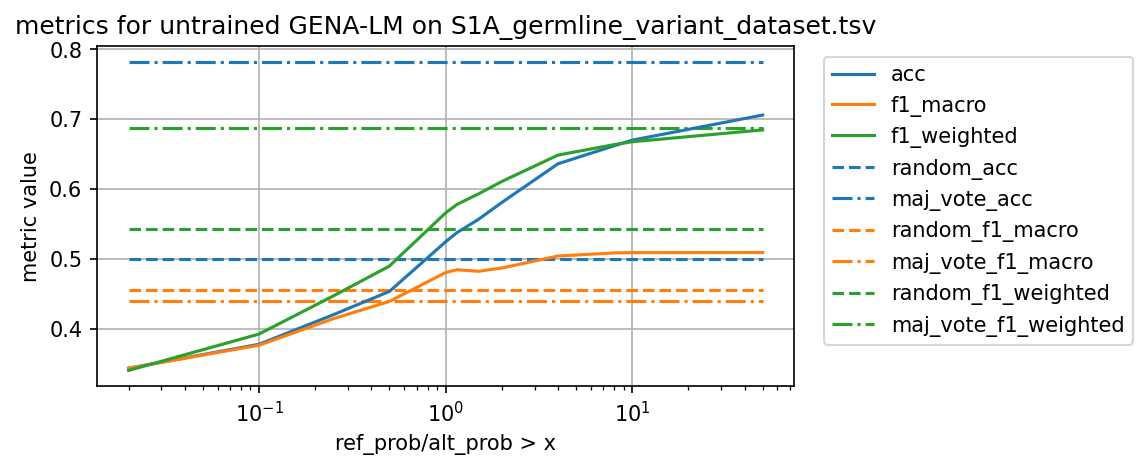

In [293]:
# accuracy, f1-micro, f1-macro, f1-weighted
from sklearn.metrics import accuracy_score, f1_score
from functools import partial

# random prediction metrics
# print('random:')
# import random
# print(f1_score(predictions_df['pathogenic'], [random.randint(a=0, b=1) for i in range(len(predictions_df))]))
acc = []
f1_micro = []
f1_macro = []
f1_weighted = []
colors = sns.color_palette()
plt.figure(figsize=(6, 3), dpi=150)
for i, (metric_name, metric_fn) in enumerate(zip(['acc', 'f1_macro', 'f1_weighted'], [accuracy_score, partial(f1_score, average='macro'), partial(f1_score, average='weighted')])):
    metrics_values = [metric_fn(predictions_df['pathogenic'], predictions_df[f'prediction_{scale}']) for scale in scales]
    plt.plot(scales, metrics_values, label=metric_name, color=colors[i])
    # get random data metrics (0.5 prob), get 10 times avg for more stable results
    rand_metric_value = np.mean([metric_fn(predictions_df['pathogenic'], [random.randint(a=0, b=1) for i in range(len(predictions_df))]) for _ in range(10)])
    plt.hlines(rand_metric_value, xmin=min(scales), xmax=max(scales), label=f'random_{metric_name}', linestyles='--', colors=colors[i])
    maj_vote = predictions_df['pathogenic'].value_counts().argmax()
    maj_vote_metric_value = metric_fn(predictions_df['pathogenic'], [maj_vote] * len(predictions_df))
    plt.hlines(maj_vote_metric_value, xmin=min(scales), xmax=max(scales), label=f'maj_vote_{metric_name}', linestyles='-.', colors=colors[i])
plt.grid()
# plt.legend()
plt.title(f'metrics for untrained GENA-LM on {data_file.name}')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
plt.xscale('log')
plt.xlabel('ref_prob/alt_prob > x')
plt.ylabel('metric value')
plt.show()

### S1C eQTLvariant

In [297]:
data_file = Path('../data/genomes/downstream_tasks/pathogenic_mutations/S1C_eQTL_variant_dataset.tsv')
data = PathogenicMutationsDataset(data_file=data_file, tokenizer=tokenizer, max_seq_len=128)

In [304]:
predictions = []
for x in tqdm(data):
    with torch.no_grad():
        inputs = prepare_model_input(x, cuda=True)
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
    ref = x['ref']
    alt = x['alt']
    mask_token_index = (inputs['input_ids'] == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    ref_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(ref)].item()
    alt_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(alt)].item()
    predictions += [{'ref_prob': ref_prob,
                     'alt_prob': alt_prob,
                     'ref': ref,
                     'alt': alt,
                     'pathogenic': x['pathogenic']
                  }]

In [309]:
import pandas as pd
predictions_df = pd.DataFrame(predictions)

predictions_df['ref_prob>alt_prob'] = predictions_df['ref_prob'] > predictions_df['alt_prob']
predictions_df['ref_prob-alt_prob'] = predictions_df['ref_prob'] - predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob'] = predictions_df['ref_prob'] / predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob_in_[0.5,2.0]'] = (predictions_df['ref_prob/alt_prob']<2.0)&(predictions_df['ref_prob/alt_prob']>0.5)
predictions_df['ref_prob/alt_prob_in_[0.1,10.0]'] = (predictions_df['ref_prob/alt_prob']<10.0)&(predictions_df['ref_prob/alt_prob']>0.1)
predictions_df['ref_prob/alt_prob_in_[0.01,100.0]'] = (predictions_df['ref_prob/alt_prob']<100.0)&(predictions_df['ref_prob/alt_prob']>0.01)

In [306]:
scales = [1/50, 0.1, 0.25, 0.5, 1.0, 1.15, 1.5, 2.0, 4.0, 8.0, 10, 50]
for scale in scales:
    predictions_df[f'prediction_{scale}'] = predictions_df.apply(lambda x: get_label(x['ref_prob'], x['alt_prob'], scale=scale), axis=1)

In [307]:
predictions_df.corr()

,ref_prob,alt_prob,pathogenic,ref_prob>alt_prob,ref_prob-alt_prob,ref_prob/alt_prob,"ref_prob/alt_prob_in_[0.5,2.0]","ref_prob/alt_prob_in_[0.1,10.0]","ref_prob/alt_prob_in_[0.01,100.0]",prediction_0.02,...,prediction_0.25,prediction_0.5,prediction_1.0,prediction_1.15,prediction_1.5,prediction_2.0,prediction_4.0,prediction_8.0,prediction_10,prediction_50
ref_prob,1.000000,-0.126832,-0.105616,0.422816,0.759943,0.033552,-0.122058,-0.211762,-0.229089,0.242724,...,0.333801,0.371995,0.422816,0.435221,0.456501,0.474240,0.514545,0.538374,0.539754,0.526932
alt_prob,-0.126832,1.000000,-0.096096,-0.416584,-0.741125,-0.004188,-0.120313,-0.213222,-0.224148,-0.510291,...,-0.502924,-0.465214,-0.416584,-0.404689,-0.384513,-0.366683,-0.328234,-0.299138,-0.291641,-0.237432
pathogenic,-0.105616,-0.096096,1.000000,-0.000603,-0.008514,-0.007904,0.038117,0.035267,0.028316,0.014615,...,0.014640,0.014227,-0.000603,-0.005733,-0.014825,-0.017350,-0.026889,-0.025885,-0.025752,-0.023046
ref_prob>alt_prob,0.422816,-0.416584,-0.000603,1.000000,0.559156,0.008308,0.007176,0.012922,0.006244,0.486344,...,0.701605,0.812409,1.000000,0.952596,0.877153,0.808657,0.694783,0.619204,0.599948,0.476636
ref_prob-alt_prob,0.759943,-0.741125,-0.008514,0.559156,1.000000,0.025454,-0.003774,-0.003606,-0.008175,0.498667,...,0.555484,0.556624,0.559156,0.559757,0.560939,0.561262,0.563347,0.560409,0.556430,0.512230
ref_prob/alt_prob,0.033552,-0.004188,-0.007904,0.008308,0.025454,1.000000,-0.004227,-0.007716,-0.012401,0.004040,...,0.005829,0.006749,0.008308,0.008721,0.009471,0.010273,0.011957,0.013416,0.013847,0.017428
"ref_prob/alt_prob_in_[0.5,2.0]",-0.122058,-0.120313,0.038117,0.007176,-0.003774,-0.004227,1.000000,0.547802,0.340764,0.249547,...,0.359999,0.416853,0.007176,-0.087899,-0.250022,-0.411442,-0.353504,-0.315049,-0.305251,-0.242511
"ref_prob/alt_prob_in_[0.1,10.0]",-0.211762,-0.213222,0.035267,0.012922,-0.003606,-0.007716,0.547802,1.000000,0.622057,0.455543,...,0.401667,0.237531,0.012922,-0.039148,-0.127890,-0.216187,-0.385296,-0.519332,-0.557229,-0.442698
"ref_prob/alt_prob_in_[0.01,100.0]",-0.229089,-0.224148,0.028316,0.006244,-0.008175,-0.012401,0.340764,0.622057,1.000000,0.531386,...,0.247955,0.145926,0.006244,-0.026149,-0.081365,-0.136316,-0.241593,-0.325061,-0.348665,-0.532611
prediction_0.02,0.242724,-0.510291,0.014615,0.486344,0.498667,0.004040,0.249547,0.455543,0.531386,1.000000,...,0.693188,0.598645,0.486344,0.463290,0.426598,0.393286,0.337904,0.301147,0.291781,0.231809


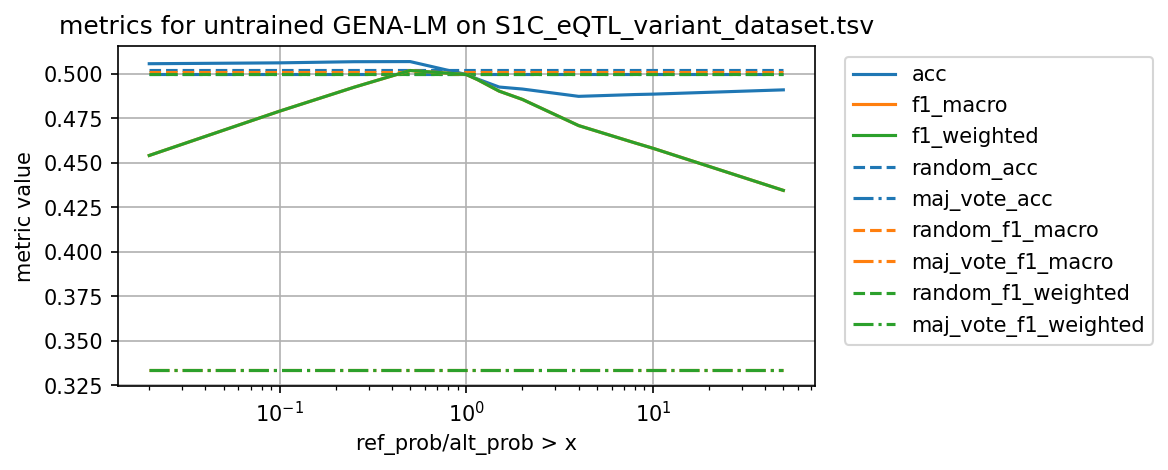

In [308]:
# accuracy, f1-micro, f1-macro, f1-weighted
from sklearn.metrics import accuracy_score, f1_score
from functools import partial

# random prediction metrics
# print('random:')
# import random
# print(f1_score(predictions_df['pathogenic'], [random.randint(a=0, b=1) for i in range(len(predictions_df))]))
acc = []
f1_micro = []
f1_macro = []
f1_weighted = []
colors = sns.color_palette()
plt.figure(figsize=(6, 3), dpi=150)
for i, (metric_name, metric_fn) in enumerate(zip(['acc', 'f1_macro', 'f1_weighted'], [accuracy_score, partial(f1_score, average='macro'), partial(f1_score, average='weighted')])):
    metrics_values = [metric_fn(predictions_df['pathogenic'], predictions_df[f'prediction_{scale}']) for scale in scales]
    plt.plot(scales, metrics_values, label=metric_name, color=colors[i])
    # get random data metrics (0.5 prob), get 10 times avg for more stable results
    rand_metric_value = np.mean([metric_fn(predictions_df['pathogenic'], [random.randint(a=0, b=1) for i in range(len(predictions_df))]) for _ in range(10)])
    plt.hlines(rand_metric_value, xmin=min(scales), xmax=max(scales), label=f'random_{metric_name}', linestyles='--', colors=colors[i])
    maj_vote = predictions_df['pathogenic'].value_counts().argmax()
    maj_vote_metric_value = metric_fn(predictions_df['pathogenic'], [maj_vote] * len(predictions_df))
    plt.hlines(maj_vote_metric_value, xmin=min(scales), xmax=max(scales), label=f'maj_vote_{metric_name}', linestyles='-.', colors=colors[i])
plt.grid()
# plt.legend()
plt.title(f'metrics for untrained GENA-LM on {data_file.name}')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
plt.xscale('log')
plt.xlabel('ref_prob/alt_prob > x')
plt.ylabel('metric value')
plt.show()

### S1D GWAS variant

In [313]:
data_file = Path('../data/genomes/downstream_tasks/pathogenic_mutations/S1D_GWAS_variant_dataset.tsv')
data = PathogenicMutationsDataset(data_file=data_file, tokenizer=tokenizer, max_seq_len=128)

In [314]:
predictions = []
for x in tqdm(data):
    with torch.no_grad():
        inputs = prepare_model_input(x, cuda=True)
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
    ref = x['ref']
    alt = x['alt']
    mask_token_index = (inputs['input_ids'] == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    ref_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(ref)].item()
    alt_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(alt)].item()
    predictions += [{'ref_prob': ref_prob,
                     'alt_prob': alt_prob,
                     'ref': ref,
                     'alt': alt,
                     'pathogenic': x['pathogenic']
                  }]

In [315]:
import pandas as pd
predictions_df = pd.DataFrame(predictions)

predictions_df['ref_prob>alt_prob'] = predictions_df['ref_prob'] > predictions_df['alt_prob']
predictions_df['ref_prob-alt_prob'] = predictions_df['ref_prob'] - predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob'] = predictions_df['ref_prob'] / predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob_in_[0.5,2.0]'] = (predictions_df['ref_prob/alt_prob']<2.0)&(predictions_df['ref_prob/alt_prob']>0.5)
predictions_df['ref_prob/alt_prob_in_[0.1,10.0]'] = (predictions_df['ref_prob/alt_prob']<10.0)&(predictions_df['ref_prob/alt_prob']>0.1)
predictions_df['ref_prob/alt_prob_in_[0.01,100.0]'] = (predictions_df['ref_prob/alt_prob']<100.0)&(predictions_df['ref_prob/alt_prob']>0.01)

In [316]:
scales = [1/50, 0.1, 0.25, 0.5, 1.0, 1.15, 1.5, 2.0, 4.0, 8.0, 10, 50]
for scale in scales:
    predictions_df[f'prediction_{scale}'] = predictions_df.apply(lambda x: get_label(x['ref_prob'], x['alt_prob'], scale=scale), axis=1)

In [317]:
predictions_df.corr()

,ref_prob,alt_prob,pathogenic,ref_prob>alt_prob,ref_prob-alt_prob,ref_prob/alt_prob,"ref_prob/alt_prob_in_[0.5,2.0]","ref_prob/alt_prob_in_[0.1,10.0]","ref_prob/alt_prob_in_[0.01,100.0]",prediction_0.02,...,prediction_0.25,prediction_0.5,prediction_1.0,prediction_1.15,prediction_1.5,prediction_2.0,prediction_4.0,prediction_8.0,prediction_10,prediction_50
ref_prob,1.000000,-0.160461,-0.009516,0.457993,0.777115,0.030273,-0.127994,-0.206976,-0.220410,0.267353,...,0.371194,0.407863,0.457993,0.468721,0.489299,0.507554,0.540183,0.557099,0.558023,0.540411
alt_prob,-0.160461,1.000000,0.007162,-0.456314,-0.745900,-0.005202,-0.116969,-0.196599,-0.218686,-0.529631,...,-0.531681,-0.502986,-0.456314,-0.445975,-0.425930,-0.407160,-0.368865,-0.337616,-0.328560,-0.262539
pathogenic,-0.009516,0.007162,1.000000,-0.011591,-0.010988,-0.000036,0.001916,0.000596,-0.005083,-0.006223,...,-0.004455,-0.008414,-0.011591,-0.011472,-0.010327,-0.009894,-0.009839,-0.007760,-0.005941,-0.001314
ref_prob>alt_prob,0.457993,-0.456314,-0.011591,1.000000,0.600010,0.009390,-0.000757,0.008973,0.012238,0.496842,...,0.724197,0.827427,1.000000,0.958160,0.886619,0.823569,0.713897,0.637150,0.616071,0.479664
ref_prob-alt_prob,0.777115,-0.745900,-0.010988,0.600010,1.000000,0.023745,-0.011789,-0.014312,-0.009294,0.518114,...,0.589493,0.595941,0.600010,0.600657,0.601762,0.602112,0.599713,0.591202,0.586052,0.532071
ref_prob/alt_prob,0.030273,-0.005202,-0.000036,0.009390,0.023745,1.000000,-0.004615,-0.008483,-0.014089,0.004665,...,0.006800,0.007770,0.009390,0.009800,0.010591,0.011402,0.013153,0.014737,0.015241,0.019572
"ref_prob/alt_prob_in_[0.5,2.0]",-0.127994,-0.116969,0.001916,-0.000757,-0.011789,-0.004615,1.000000,0.543992,0.327395,0.236221,...,0.344316,0.393396,-0.000757,-0.089188,-0.250270,-0.404783,-0.350880,-0.313159,-0.302798,-0.235755
"ref_prob/alt_prob_in_[0.1,10.0]",-0.206976,-0.196599,0.000596,0.008973,-0.014312,-0.008483,0.543992,1.000000,0.601839,0.434236,...,0.378912,0.223587,0.008973,-0.039131,-0.126711,-0.210668,-0.376987,-0.514694,-0.556623,-0.433379
"ref_prob/alt_prob_in_[0.01,100.0]",-0.220410,-0.218686,-0.005083,0.012238,-0.009294,-0.014089,0.327395,0.601839,1.000000,0.528766,...,0.235279,0.141546,0.012238,-0.016711,-0.069386,-0.119843,-0.219694,-0.302271,-0.327398,-0.527947
prediction_0.02,0.267353,-0.529631,-0.006223,0.496842,0.518114,0.004665,0.236221,0.434236,0.528766,1.000000,...,0.686058,0.600466,0.496842,0.476054,0.440509,0.409183,0.354694,0.316562,0.306090,0.238317


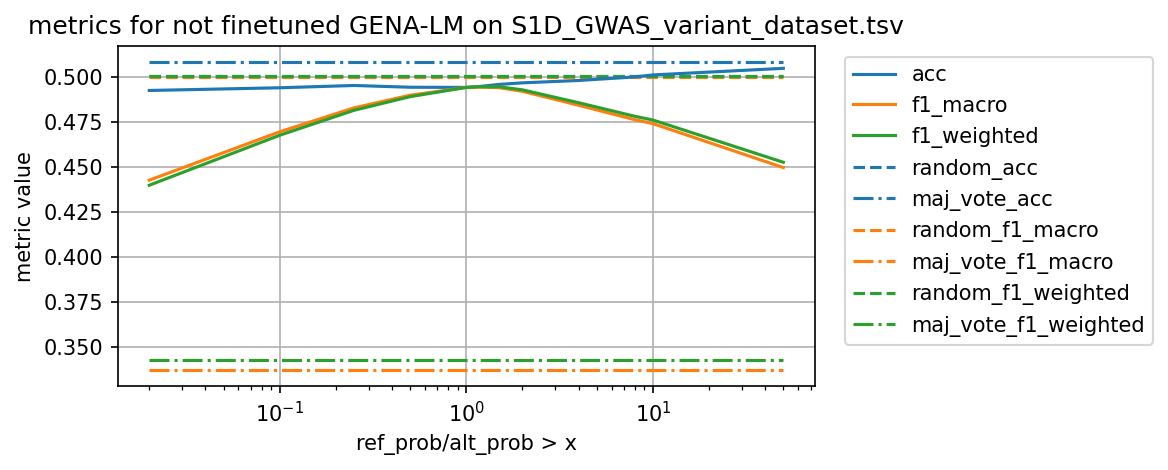

In [319]:
# accuracy, f1-micro, f1-macro, f1-weighted
from sklearn.metrics import accuracy_score, f1_score
from functools import partial

acc = []
f1_micro = []
f1_macro = []
f1_weighted = []
colors = sns.color_palette()
plt.figure(figsize=(6, 3), dpi=150)
for i, (metric_name, metric_fn) in enumerate(zip(['acc', 'f1_macro', 'f1_weighted'], [accuracy_score, partial(f1_score, average='macro'), partial(f1_score, average='weighted')])):
    metrics_values = [metric_fn(predictions_df['pathogenic'], predictions_df[f'prediction_{scale}']) for scale in scales]
    plt.plot(scales, metrics_values, label=metric_name, color=colors[i])
    # get random data metrics (0.5 prob), get 10 times avg for more stable results
    rand_metric_value = np.mean([metric_fn(predictions_df['pathogenic'], [random.randint(a=0, b=1) for i in range(len(predictions_df))]) for _ in range(10)])
    plt.hlines(rand_metric_value, xmin=min(scales), xmax=max(scales), label=f'random_{metric_name}', linestyles='--', colors=colors[i])
    maj_vote = predictions_df['pathogenic'].value_counts().argmax()
    maj_vote_metric_value = metric_fn(predictions_df['pathogenic'], [maj_vote] * len(predictions_df))
    plt.hlines(maj_vote_metric_value, xmin=min(scales), xmax=max(scales), label=f'maj_vote_{metric_name}', linestyles='-.', colors=colors[i])
plt.grid()
# plt.legend()
plt.title(f'metrics for not finetuned GENA-LM on {data_file.name}')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
plt.xscale('log')
plt.xlabel('ref_prob/alt_prob > x')
plt.ylabel('metric value')
plt.show()

### S1B somatic variant

In [321]:
data_file = Path('../data/genomes/downstream_tasks/pathogenic_mutations/S1B_somatic_variant_dataset.shuffled.10k.tsv')
data = PathogenicMutationsDataset(data_file=data_file, tokenizer=tokenizer, max_seq_len=128)

In [322]:
predictions = []
for x in tqdm(data):
    with torch.no_grad():
        inputs = prepare_model_input(x, cuda=True)
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
    ref = x['ref']
    alt = x['alt']
    mask_token_index = (inputs['input_ids'] == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    ref_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(ref)].item()
    alt_prob = probs[0, mask_token_index, tokenizer.convert_tokens_to_ids(alt)].item()
    predictions += [{'ref_prob': ref_prob,
                     'alt_prob': alt_prob,
                     'ref': ref,
                     'alt': alt,
                     'pathogenic': x['pathogenic']
                  }]

In [323]:
import pandas as pd
predictions_df = pd.DataFrame(predictions)

predictions_df['ref_prob>alt_prob'] = predictions_df['ref_prob'] > predictions_df['alt_prob']
predictions_df['ref_prob-alt_prob'] = predictions_df['ref_prob'] - predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob'] = predictions_df['ref_prob'] / predictions_df['alt_prob']
predictions_df['ref_prob/alt_prob_in_[0.5,2.0]'] = (predictions_df['ref_prob/alt_prob']<2.0)&(predictions_df['ref_prob/alt_prob']>0.5)
predictions_df['ref_prob/alt_prob_in_[0.1,10.0]'] = (predictions_df['ref_prob/alt_prob']<10.0)&(predictions_df['ref_prob/alt_prob']>0.1)
predictions_df['ref_prob/alt_prob_in_[0.01,100.0]'] = (predictions_df['ref_prob/alt_prob']<100.0)&(predictions_df['ref_prob/alt_prob']>0.01)

In [324]:
scales = [1/50, 0.1, 0.25, 0.5, 1.0, 1.15, 1.5, 2.0, 4.0, 8.0, 10, 50]
for scale in scales:
    predictions_df[f'prediction_{scale}'] = predictions_df.apply(lambda x: get_label(x['ref_prob'], x['alt_prob'], scale=scale), axis=1)

In [325]:
predictions_df.corr()

,ref_prob,alt_prob,pathogenic,ref_prob>alt_prob,ref_prob-alt_prob,ref_prob/alt_prob,"ref_prob/alt_prob_in_[0.5,2.0]","ref_prob/alt_prob_in_[0.1,10.0]","ref_prob/alt_prob_in_[0.01,100.0]",prediction_0.02,...,prediction_0.25,prediction_0.5,prediction_1.0,prediction_1.15,prediction_1.5,prediction_2.0,prediction_4.0,prediction_8.0,prediction_10,prediction_50
ref_prob,1.000000,-0.090672,-0.013398,0.380716,0.740605,0.076687,-0.116027,-0.200038,-0.194791,0.230949,...,0.305444,0.337671,0.380716,0.389694,0.413247,0.436255,0.477934,0.507528,0.515225,0.498764
alt_prob,-0.090672,1.000000,0.000358,-0.394268,-0.736325,-0.008001,-0.111801,-0.202411,-0.234273,-0.469645,...,-0.472838,-0.439818,-0.394268,-0.384628,-0.360835,-0.339219,-0.299036,-0.267969,-0.259972,-0.209178
pathogenic,-0.013398,0.000358,1.000000,0.003690,-0.009345,-0.000960,0.000857,0.005219,0.000907,-0.003506,...,-0.002852,0.001303,0.003690,-0.000420,-0.004846,0.000547,-0.004685,-0.009721,-0.012215,-0.016125
ref_prob>alt_prob,0.380716,-0.394268,0.003690,1.000000,0.524689,0.016290,0.013597,0.056615,0.067074,0.494731,...,0.689135,0.794963,1.000000,0.951410,0.855454,0.777296,0.653161,0.570323,0.550836,0.431984
ref_prob-alt_prob,0.740605,-0.736325,-0.009345,0.524689,1.000000,0.057501,-0.003398,0.000660,0.025723,0.473792,...,0.526560,0.526177,0.524689,0.524285,0.524234,0.525281,0.526487,0.525632,0.525466,0.480010
ref_prob/alt_prob,0.076687,-0.008001,-0.000960,0.016290,0.057501,1.000000,-0.009301,-0.016732,-0.026817,0.008059,...,0.011226,0.012950,0.016290,0.017122,0.019042,0.020956,0.024938,0.028559,0.029569,0.037692
"ref_prob/alt_prob_in_[0.5,2.0]",-0.116027,-0.111801,0.000857,0.013597,-0.003398,-0.009301,1.000000,0.555831,0.346519,0.267767,...,0.372986,0.430264,0.013597,-0.076005,-0.268160,-0.443872,-0.372986,-0.325681,-0.314553,-0.246683
"ref_prob/alt_prob_in_[0.1,10.0]",-0.200038,-0.202411,0.005219,0.056615,0.000660,-0.016732,0.555831,1.000000,0.623425,0.481742,...,0.441930,0.289813,0.056615,0.006806,-0.099601,-0.196431,-0.377519,-0.526322,-0.565915,-0.443809
"ref_prob/alt_prob_in_[0.01,100.0]",-0.194791,-0.234273,0.000907,0.067074,0.025723,-0.026817,0.346519,0.623425,1.000000,0.561336,...,0.309841,0.213492,0.067074,0.036019,-0.030061,-0.089884,-0.201024,-0.291704,-0.315746,-0.496171
prediction_0.02,0.230949,-0.469645,-0.003506,0.494731,0.473792,0.008059,0.267767,0.481742,0.561336,1.000000,...,0.717902,0.622332,0.494731,0.470692,0.423220,0.384552,0.323139,0.282157,0.272516,0.213716


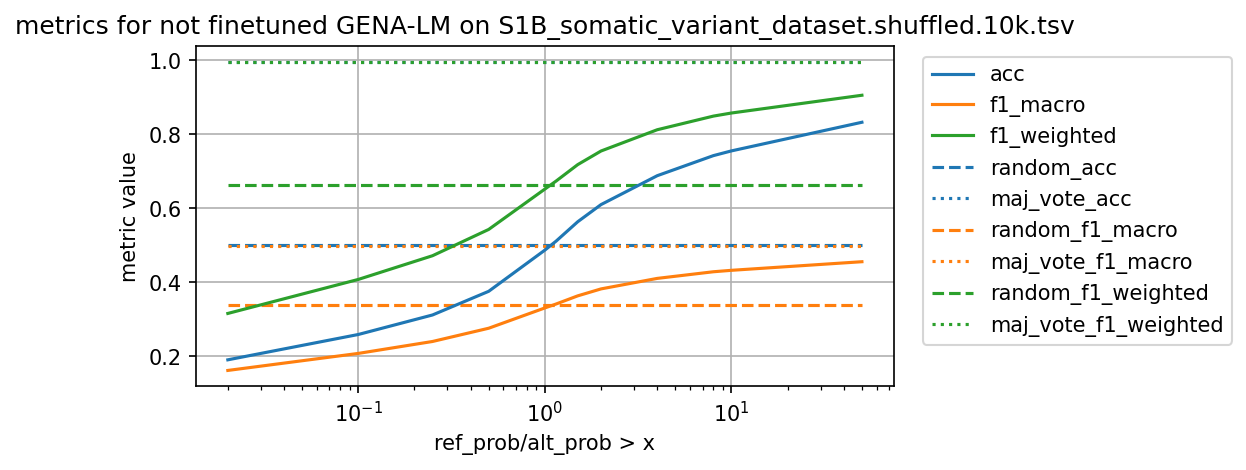

In [328]:
# accuracy, f1-micro, f1-macro, f1-weighted
from sklearn.metrics import accuracy_score, f1_score
from functools import partial

acc = []
f1_micro = []
f1_macro = []
f1_weighted = []
colors = sns.color_palette()
plt.figure(figsize=(6, 3), dpi=150)
for i, (metric_name, metric_fn) in enumerate(zip(['acc', 'f1_macro', 'f1_weighted'], [accuracy_score, partial(f1_score, average='macro'), partial(f1_score, average='weighted')])):
    metrics_values = [metric_fn(predictions_df['pathogenic'], predictions_df[f'prediction_{scale}']) for scale in scales]
    plt.plot(scales, metrics_values, label=metric_name, color=colors[i])
    # get random data metrics (0.5 prob), get 10 times avg for more stable results
    rand_metric_value = np.mean([metric_fn(predictions_df['pathogenic'], [random.randint(a=0, b=1) for i in range(len(predictions_df))]) for _ in range(10)])
    plt.hlines(rand_metric_value, xmin=min(scales), xmax=max(scales), label=f'random_{metric_name}', linestyles='--', colors=colors[i])
    maj_vote = predictions_df['pathogenic'].value_counts().argmax()
    maj_vote_metric_value = metric_fn(predictions_df['pathogenic'], [maj_vote] * len(predictions_df))
    plt.hlines(maj_vote_metric_value, xmin=min(scales), xmax=max(scales), label=f'maj_vote_{metric_name}', linestyles='dotted', colors=colors[i])
plt.grid()
# plt.legend()
plt.title(f'metrics for not finetuned GENA-LM on {data_file.name}')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
plt.xscale('log')
plt.xlabel('ref_prob/alt_prob > x')
plt.ylabel('metric value')
plt.show()